In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
health_df=pd.read_csv(r"C:\Users\Asus\Desktop\ml\Mental_Health_and_Social_Media_Balance_Dataset.csv")

In [3]:
health_df.head()

,User_ID,Age,Gender,Daily_Screen_Time(hrs),Sleep_Quality(1-10),Stress_Level(1-10),Days_Without_Social_Media,Exercise_Frequency(week),Social_Media_Platform,Happiness_Index(1-10)
0,U001,44,Male,3.1,7.0,6.0,2.0,5.0,Facebook,10.0
1,U002,30,Other,5.1,7.0,8.0,5.0,3.0,LinkedIn,10.0
2,U003,23,Other,7.4,6.0,7.0,1.0,3.0,YouTube,6.0
3,U004,36,Female,5.7,7.0,8.0,1.0,1.0,TikTok,8.0
4,U005,34,Female,7.0,4.0,7.0,5.0,1.0,X (Twitter),8.0


In [4]:
health_df.isnull().sum()

User_ID                      0
Age                          0
Gender                       0
Daily_Screen_Time(hrs)       0
Sleep_Quality(1-10)          0
Stress_Level(1-10)           0
Days_Without_Social_Media    0
Exercise_Frequency(week)     0
Social_Media_Platform        0
Happiness_Index(1-10)        0
dtype: int64

In [5]:
health_df.describe()

,Age,Daily_Screen_Time(hrs),Sleep_Quality(1-10),Stress_Level(1-10),Days_Without_Social_Media,Exercise_Frequency(week),Happiness_Index(1-10)
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,32.988000,5.530000,6.304000,6.618000,3.134000,2.448000,8.376000
std,9.960637,1.734877,1.529792,1.542996,1.858751,1.428067,1.524228
min,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,4.000000
25%,24.000000,4.300000,5.000000,6.000000,2.000000,1.000000,7.000000
50%,34.000000,5.600000,6.000000,7.000000,3.000000,2.000000,9.000000
75%,41.000000,6.700000,7.000000,8.000000,5.000000,3.000000,10.000000
max,49.000000,10.800000,10.000000,10.000000,9.000000,7.000000,10.000000


In [6]:
health_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   User_ID                    500 non-null    object 
 1   Age                        500 non-null    int64  
 2   Gender                     500 non-null    object 
 3   Daily_Screen_Time(hrs)     500 non-null    float64
 4   Sleep_Quality(1-10)        500 non-null    float64
 5   Stress_Level(1-10)         500 non-null    float64
 6   Days_Without_Social_Media  500 non-null    float64
 7   Exercise_Frequency(week)   500 non-null    float64
 8   Social_Media_Platform      500 non-null    object 
 9   Happiness_Index(1-10)      500 non-null    float64
dtypes: float64(6), int64(1), object(3)
memory usage: 39.2+ KB


In [7]:
health_df=health_df.drop(['User_ID'], axis=1)

In [8]:
health_df.head()

,Age,Gender,Daily_Screen_Time(hrs),Sleep_Quality(1-10),Stress_Level(1-10),Days_Without_Social_Media,Exercise_Frequency(week),Social_Media_Platform,Happiness_Index(1-10)
0,44,Male,3.1,7.0,6.0,2.0,5.0,Facebook,10.0
1,30,Other,5.1,7.0,8.0,5.0,3.0,LinkedIn,10.0
2,23,Other,7.4,6.0,7.0,1.0,3.0,YouTube,6.0
3,36,Female,5.7,7.0,8.0,1.0,1.0,TikTok,8.0
4,34,Female,7.0,4.0,7.0,5.0,1.0,X (Twitter),8.0


In [9]:
health_df.Gender.value_counts()

Gender
Male      248
Female    229
Other      23
Name: count, dtype: int64

In [10]:
health_df.Social_Media_Platform.value_counts()

Social_Media_Platform
TikTok         95
X (Twitter)    88
LinkedIn       87
Facebook       81
YouTube        75
Instagram      74
Name: count, dtype: int64

In [11]:
health_df.Gender.value_counts(normalize=True)*100 # in percentage

Gender
Male      49.6
Female    45.8
Other      4.6
Name: proportion, dtype: float64

In [12]:
health_df.Social_Media_Platform.value_counts(normalize=True)*100 #in percentage

Social_Media_Platform
TikTok         19.0
X (Twitter)    17.6
LinkedIn       17.4
Facebook       16.2
YouTube        15.0
Instagram      14.8
Name: proportion, dtype: float64

In [13]:
def gender_to_num(x):
    if x=="Male": return 1
    if x=="Female": return 2
    if x== "Other": return 3

In [14]:
health_df['Gender']=health_df['Gender'].apply(gender_to_num)

In [15]:
health_df['Gender']

0      1
1      3
2      3
3      2
4      2
      ..
495    1
496    2
497    1
498    1
499    2
Name: Gender, Length: 500, dtype: int64

In [16]:
def Social_Media_Platform_to_num(y):
    if y=="TikTok": return 1
    if y=="X (Twitter)": return 2
    if y=="LinkedIn": return 3
    if y=="Facebook": return 4
    if y=="YouTube": return 5
    if y=="Instagram": return 6

In [17]:
health_df['Social_Media_Platform']=health_df['Social_Media_Platform'].apply(Social_Media_Platform_to_num)

In [18]:
health_df['Social_Media_Platform']

0      4
1      3
2      5
3      1
4      2
      ..
495    2
496    4
497    3
498    4
499    2
Name: Social_Media_Platform, Length: 500, dtype: int64

In [19]:
health_df

,Age,Gender,Daily_Screen_Time(hrs),Sleep_Quality(1-10),Stress_Level(1-10),Days_Without_Social_Media,Exercise_Frequency(week),Social_Media_Platform,Happiness_Index(1-10)
0,44,1,3.1,7.0,6.0,2.0,5.0,4,10.0
1,30,3,5.1,7.0,8.0,5.0,3.0,3,10.0
2,23,3,7.4,6.0,7.0,1.0,3.0,5,6.0
3,36,2,5.7,7.0,8.0,1.0,1.0,1,8.0
4,34,2,7.0,4.0,7.0,5.0,1.0,2,8.0
...,...,...,...,...,...,...,...,...,...
495,23,1,6.9,5.0,7.0,4.0,2.0,2,10.0
496,43,2,5.6,7.0,6.0,5.0,2.0,4,9.0
497,41,1,7.7,5.0,7.0,2.0,2.0,3,8.0
498,23,1,4.2,9.0,7.0,0.0,2.0,4,9.0


In [20]:
health_df.corr(method='pearson')

,Age,Gender,Daily_Screen_Time(hrs),Sleep_Quality(1-10),Stress_Level(1-10),Days_Without_Social_Media,Exercise_Frequency(week),Social_Media_Platform,Happiness_Index(1-10)
Age,1.000000,-0.019214,0.023505,-0.053813,0.016522,-0.025783,0.064059,0.062249,0.018513
Gender,-0.019214,1.000000,-0.050404,0.023359,-0.008796,-0.068118,0.023579,-0.018621,0.037420
Daily_Screen_Time(hrs),0.023505,-0.050404,1.000000,-0.758910,0.739891,-0.045310,-0.099023,0.106962,-0.705206
Sleep_Quality(1-10),-0.053813,0.023359,-0.758910,1.000000,-0.584899,0.040617,0.027431,-0.106067,0.678829
Stress_Level(1-10),0.016522,-0.008796,0.739891,-0.584899,1.000000,-0.007970,-0.018582,0.078261,-0.737213
Days_Without_Social_Media,-0.025783,-0.068118,-0.045310,0.040617,-0.007970,1.000000,-0.000012,-0.085558,0.063525
Exercise_Frequency(week),0.064059,0.023579,-0.099023,0.027431,-0.018582,-0.000012,1.000000,0.001315,0.041224
Social_Media_Platform,0.062249,-0.018621,0.106962,-0.106067,0.078261,-0.085558,0.001315,1.000000,-0.095362
Happiness_Index(1-10),0.018513,0.037420,-0.705206,0.678829,-0.737213,0.063525,0.041224,-0.095362,1.000000


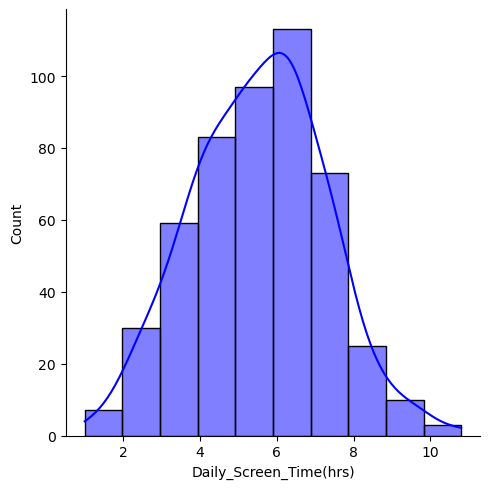

In [21]:
sns.displot(health_df, x= 'Daily_Screen_Time(hrs)', bins=10,kde=True,color='Blue')
plt.savefig("Daily_Screen_Time")
plt.show()

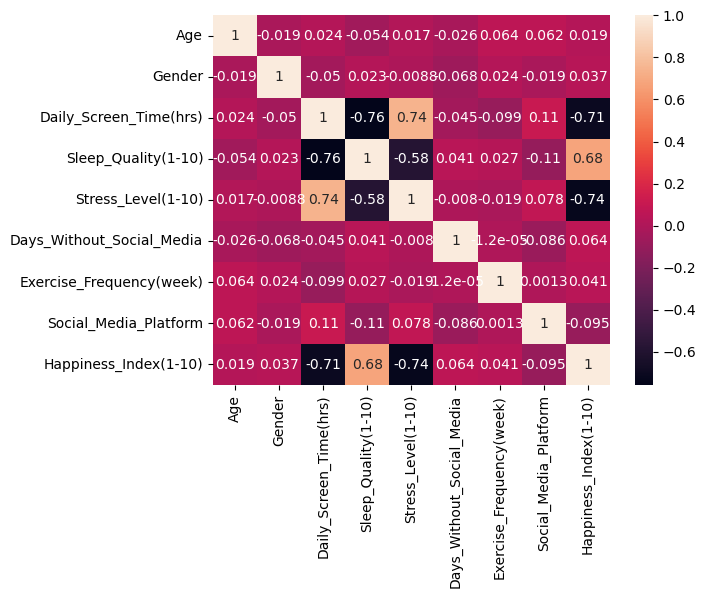

In [22]:
sns.heatmap(health_df.corr(),annot=True)
plt.savefig("health_df")
plt.show()

In [23]:
health_df.head()

,Age,Gender,Daily_Screen_Time(hrs),Sleep_Quality(1-10),Stress_Level(1-10),Days_Without_Social_Media,Exercise_Frequency(week),Social_Media_Platform,Happiness_Index(1-10)
0,44,1,3.1,7.0,6.0,2.0,5.0,4,10.0
1,30,3,5.1,7.0,8.0,5.0,3.0,3,10.0
2,23,3,7.4,6.0,7.0,1.0,3.0,5,6.0
3,36,2,5.7,7.0,8.0,1.0,1.0,1,8.0
4,34,2,7.0,4.0,7.0,5.0,1.0,2,8.0


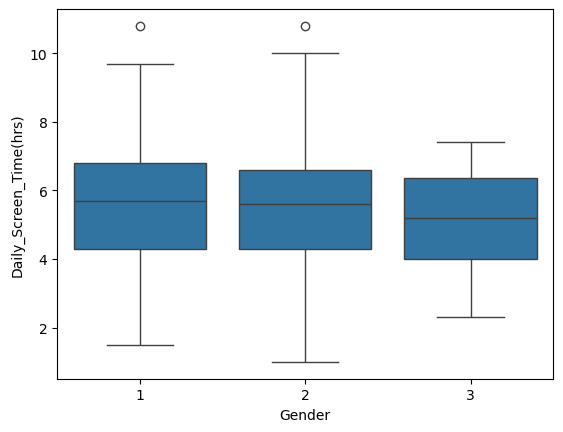

In [24]:
sns.boxplot(x='Gender', y='Daily_Screen_Time(hrs)', data=health_df)
plt.savefig("Daily_Screen_Time")
plt.show()

In [25]:
health_df.columns.values

array(['Age', 'Gender', 'Daily_Screen_Time(hrs)', 'Sleep_Quality(1-10)',
       'Stress_Level(1-10)', 'Days_Without_Social_Media',
       'Exercise_Frequency(week)', 'Social_Media_Platform',
       'Happiness_Index(1-10)'], dtype=object)

In [26]:
mental_health_df = ['Age', 'Gender', 'Daily_Screen_Time(hrs)', 'Sleep_Quality(1-10)','Stress_Level(1-10)', 'Days_Without_Social_Media','Exercise_Frequency(week)', 'Social_Media_Platform','Happiness_Index(1-10)']

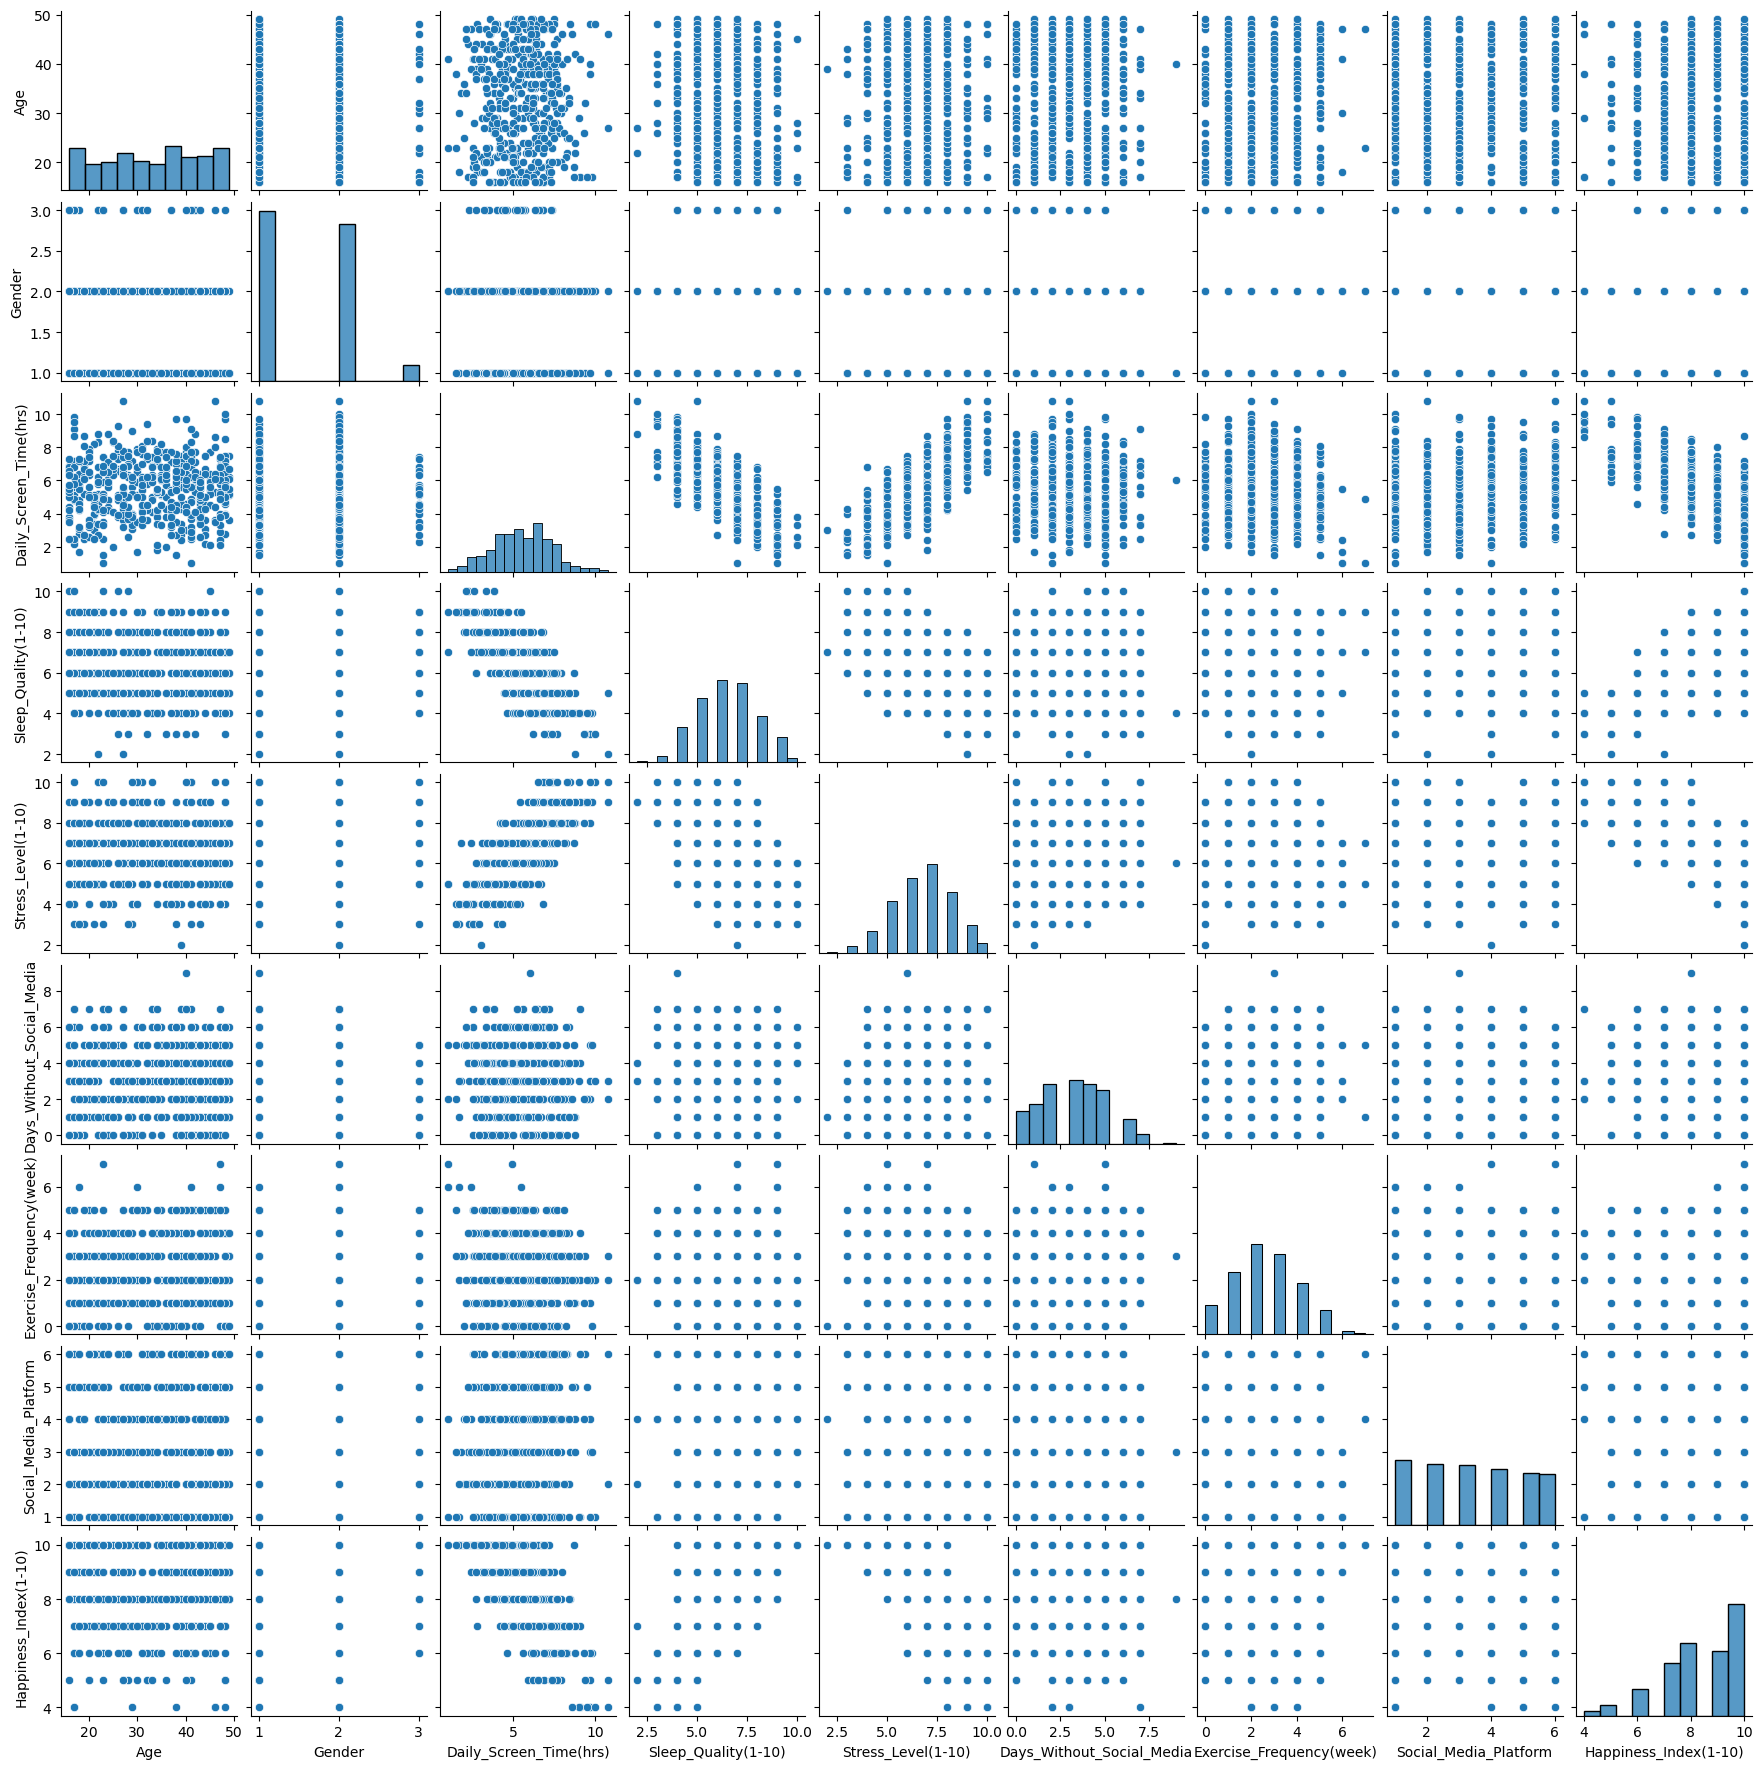

In [27]:
sns.pairplot(health_df[mental_health_df], size=2)
plt.savefig("health_df[mental_health_df]")
plt.show()